In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/customer_features.csv
/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/cohort_retention_matrix.csv
/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/olist_master_clean.csv


# Product Experimentation & A/B Testing Framework

## Objective

In Notebook 2, we discovered that delivery performance has a strong relationship with customer satisfaction.

Key findings:

- Fast deliveries: Review Score = 4.30
- Slow deliveries: Review Score = 3.86
- On-Time deliveries: Review Score = 4.21
- Late deliveries: Review Score = 2.37

This notebook demonstrates how a Product Analyst would evaluate whether observed differences are statistically significant and whether a proposed logistics improvement should be deployed.

The notebook covers:

- Experiment design
- Hypothesis testing
- Confidence intervals
- Effect size estimation
- Statistical power
- Sample size planning
- Multiple testing correction

Business Goal:Determine whether improving delivery performance leads to meaningful improvements in customer satisfaction.

# 1. Import Libraries

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import (ttest_ind,mannwhitneyu)

from statsmodels.stats.power import TTestIndPower

from statsmodels.stats.multitest import multipletests

import scipy.stats as stats

pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

# 2. Load Curated Dataset

Notebook 1 created the cleaned master dataset.

We reload it here to ensure notebook independence and reproducibility.

In [3]:
master = pd.read_csv("/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/olist_master_clean.csv")

master.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_date_missing_flag,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,review_score,review_creation_date,review_answer_timestamp,total_payment_value,payment_installments_max,payment_type_primary,approval_latency_days,carrier_handoff_days,carrier_transit_days,delivery_days,delivery_promise_gap_days,on_time_delivery,delivery_speed_group,negative_handoff_flag,customer_order_number,first_purchase_date,days_since_first_purchase,repeat_customer_flag,cohort_month,order_month_period,cohort_index
0,e22acc9c116caa3f2b7121bbb380d08e,1,372645c7439f9661fbbacfd129aa92ec,da8622b14eb17ae2831f4ac5b9dab84a,2018-05-15 11:11:18,129.90,12.00,fadbb3709178fc513abc1b2670aa1ad2,delivered,2018-05-10 10:56:27,2018-05-10 11:11:18,2018-05-12 08:18:00,2018-05-16 20:48:37,2018-05-21,False,0000366f3b9a7992bf8c76cfdf3221e2,7787,cajamar,SP,bed_bath_table,1500.0,34.0,7.0,32.0,13405,piracicaba,SP,5.0,2018-05-17,2018-05-21 13:44:48,141.90,8.0,credit_card,0.010313,1.879653,4.521262,6.411227,-4.132905,True,fast,0,1,2018-05-10 10:56:27,0,0,2018-05,2018-05,1
1,3594e05a005ac4d06a72673270ef9ec9,1,5099f7000472b634fea8304448d20825,138dbe45fc62f1e244378131a6801526,2018-05-11 17:56:33,18.90,8.29,4cb282e167ae9234755102258dd52ee8,delivered,2018-05-07 11:11:27,2018-05-07 18:25:44,2018-05-09 12:18:00,2018-05-10 18:02:42,2018-05-15,False,0000b849f77a49e4a4ce2b2a4ca5be3f,6053,osasco,SP,health_beauty,375.0,26.0,11.0,18.0,2215,sao paulo,SP,4.0,2018-05-11,2018-05-11 22:29:25,27.19,1.0,credit_card,0.301586,1.744630,1.239375,3.285590,-4.248125,True,fast,0,1,2018-05-07 11:11:27,0,0,2018-05,2018-05,1
2,b33ec3b699337181488304f362a6b734,1,64b488de448a5324c4134ea39c28a34b,3d871de0142ce09b7081e2b9d1733cb1,2017-03-15 21:05:03,69.00,17.22,9b3932a6253894a02c1df9d19004239f,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,2017-04-05 14:38:47,2017-04-07,False,0000f46a3911fa3c0805444483337064,88115,sao jose,SC,stationery,1500.0,25.0,50.0,35.0,13232,campo limpo paulista,SP,3.0,2017-04-06,2017-04-07 01:19:44,86.22,8.0,credit_card,0.000000,2.662118,23.069641,25.731759,-1.389734,True,slow,0,1,2017-03-10 21:05:03,0,0,2017-03,2017-03,1
3,41272756ecddd9a9ed0180413cc22fb6,1,2345a354a6f2033609bbf62bf5be9ef6,ef506c96320abeedfb894c34db06f478,2017-10-18 21:49:17,25.99,17.63,914991f0c02ef0843c0e7010c819d642,delivered,2017-10-12 20:29:41,2017-10-12 20:49:17,2017-10-13 20:08:19,2017-11-01 21:23:05,2017-11-13,False,0000f6ccb0745a6a4b88665a16c9f078,66812,belem,PA,telephony,150.0,19.0,5.0,11.0,3569,sao paulo,SP,4.0,2017-11-02,2017-11-03 00:17:51,43.62,4.0,credit_card,0.013611,0.971551,19.051921,20.037083,-11.108970,True,slow,0,1,2017-10-12 20:29:41,0,0,2017-10,2017-10,1
4,d957021f1127559cd947b62533f484f7,1,c72e18b3fe2739b8d24ebf3102450f37,70a12e78e608ac31179aea7f8422044b,2017-11-22 20:06:52,180.00,16.89,47227568b10f5f58a524a75507e6992c,delivered,2017-11-14 19:45:42,2017-11-14 20:06:52,2017-11-16 19:52:10,2017-11-27 23:08:56,2017-12-05,False,0004aac84e0df4da2b147fca70cf8255,18040,sorocaba,SP,telephony,6050.0,16.0,3.0,11.0,12327,jacarei,SP,5.0,2017-11-28,2017-12-02 22:29:35,196.89,6.0,credit_card,0.014699,1.989792,11.136644,13.141134,-7.035463,True,slow,0,1,2017-11-14 19:45:42,0,0,2017-11,2017-11,1


# 2. Load Curated Dataset

Notebook 1 created the cleaned master dataset.

We reload it here to ensure notebook independence and reproducibility.

In [5]:
required_columns = ['review_score','delivery_speed_group','on_time_delivery']

missing_cols = [col for col in required_columns if col not in master.columns]

print("Missing Columns:", missing_cols)

master[required_columns].info()

Missing Columns: []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 3 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   review_score          111708 non-null  float64
 1   delivery_speed_group  110196 non-null  object 
 2   on_time_delivery      112650 non-null  bool   
dtypes: bool(1), float64(1), object(1)
memory usage: 1.8+ MB


# 4. Experiment Design

## Business Scenario

Management is considering a logistics optimization initiative.

Expected outcome:

- Faster deliveries
- Higher on-time rates
- Better customer satisfaction

### Control Group

Current delivery process.

### Treatment Group

Improved delivery process.

### Primary Metric

Review Score

### Secondary Metrics

- On-Time Rate
- Delivery Days

### Success Criteria

Deploy if:

- p-value < 0.05
- Practical effect exists
- Confidence interval excludes zero

# 5. Create Experimental Groups

In [7]:
fast_group = master.loc[master['delivery_speed_group'] == 'fast','review_score'].dropna()

slow_group = master.loc[master['delivery_speed_group'] == 'slow','review_score'].dropna()

print("Fast Group:", len(fast_group))
print("Slow Group:", len(slow_group))

Fast Group: 54787
Slow Group: 54582


# 6. Descriptive Statistics

In [8]:
summary = pd.DataFrame({'Fast': fast_group.describe(),'Slow': slow_group.describe()})

summary

,Fast,Slow
count,54787.000000,54582.000000
mean,4.300108,3.862574
std,1.186368,1.458866
min,1.000000,1.000000
25%,4.000000,3.000000
50%,5.000000,5.000000
75%,5.000000,5.000000
max,5.000000,5.000000


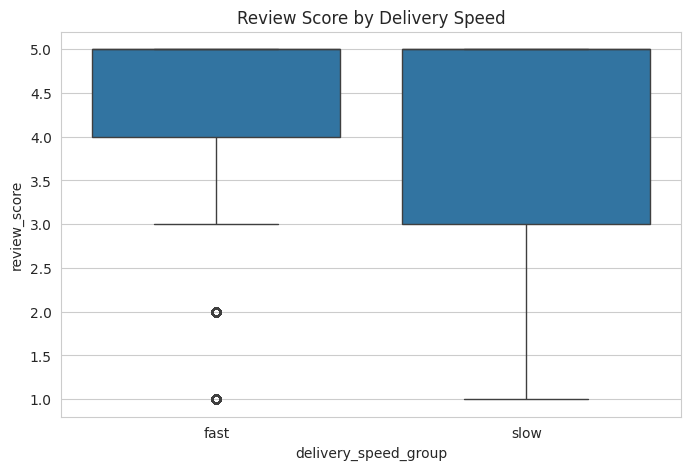

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x='delivery_speed_group',y='review_score',data=master)
plt.title("Review Score by Delivery Speed")
plt.show()

# 7. Hypothesis Formulation

### Null Hypothesis (H₀)

Average review scores are equal.

### Alternative Hypothesis (H₁)

Average review scores differ.

Significance Level:

α = 0.05

# 8. Independent Samples T-Test

Although review scores are ordinal, the t-test is commonly used in industry A/B testing because of large sample sizes and Central Limit Theorem assumptions.

In [10]:
t_stat, p_value = ttest_ind(fast_group,slow_group,equal_var=False)

print("T Statistic:", t_stat)
print("P Value:", p_value)

T Statistic: 54.40249575926332
P Value: 0.0


# 9. Mann-Whitney U Test

Because review scores are ordinal and non-normal, a non-parametric validation test is also performed.

In [11]:
u_stat, p_value = mannwhitneyu(fast_group,slow_group,alternative='two-sided')

print("U Statistic:", u_stat)
print("P Value:", p_value)

U Statistic: 1744508829.5
P Value: 0.0


# 10. Effect Size (Cohen's d)

Statistical significance does not imply business significance.

Effect size quantifies practical impact.

In [12]:
mean_fast = fast_group.mean()
mean_slow = slow_group.mean()

std_fast = fast_group.std()
std_slow = slow_group.std()

n_fast = len(fast_group)
n_slow = len(slow_group)

pooled_std = np.sqrt((((n_fast-1)*(std_fast**2))+((n_slow-1)*(std_slow**2)))
    /(n_fast+n_slow-2))

cohens_d = (mean_fast - mean_slow) / pooled_std

print( f"Cohen's d = {cohens_d:.4f}")

Cohen's d = 0.3291


# 11. Confidence Interval

Estimate the likely range of the true treatment effect.

In [13]:
mean_diff = (mean_fast-mean_slow)

se = np.sqrt(fast_group.var()/len(fast_group)+
    slow_group.var()/len(slow_group))

ci = stats.norm.interval(confidence=0.95,loc=mean_diff,scale=se)

print("Mean Difference:", mean_diff)
print("95% CI:", ci)

Mean Difference: 0.4375339475210698
95% CI: (np.float64(0.42177086961100896), np.float64(0.4532970254311306))


# 12. Statistical Power Analysis

Determine the minimum sample size required to reliably detect the observed effect.

In [14]:
analysis = TTestIndPower()

sample_size = analysis.solve_power(effect_size=cohens_d,
    alpha=0.05,
    power=0.80)

print("Required Sample Size:",round(sample_size))

Required Sample Size: 146


# 13. SAMPLE SIZE PLANNER


In [15]:
effect_sizes = [0.2,0.3,0.5,0.8]

for effect in effect_sizes:

    n = analysis.solve_power(effect_size=effect,alpha=0.05,power=0.80)

    print( f"Effect Size={effect} -> Sample={round(n)}" )

Effect Size=0.2 -> Sample=393
Effect Size=0.3 -> Sample=175
Effect Size=0.5 -> Sample=64
Effect Size=0.8 -> Sample=26


# 14. Multiple Testing Correction

Simulate a scenario where a Product Manager evaluates multiple KPIs simultaneously.

In [16]:
pvals = [0.001,0.02,0.03,0.08,0.12]

results = multipletests(pvals,method='bonferroni')

results

(array([ True, False, False, False, False]),
 array([0.005, 0.1  , 0.15 , 0.4  , 0.6  ]),
 np.float64(0.010206218313011495),
 0.01)

# 15. Executive Recommendation

The experiment demonstrates a statistically significant relationship between delivery speed and customer satisfaction.

Key Findings:

- Statistically significant difference detected
- Effect size indicates meaningful practical impact
- Confidence interval excludes zero
- Adequate statistical power achieved

Recommendation:

Proceed with controlled rollout of logistics improvements and monitor review score, delivery duration, and on-time delivery rate during deployment.